In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr, pearsonr


# Reading DataFrame and merging

In [2]:
PATH = "../../../data/raw/stad_rna_consolidated.parquet"
TARGET_PATH = "../../../data/raw/stad_tmb.parquet"

In [3]:
x = pd.read_parquet(PATH)
features_names = x.columns.tolist()
features_names

['patient_id',
 'sample_id',
 'N_unmapped',
 'N_multimapping',
 'N_noFeature',
 'N_ambiguous',
 'ENSG00000000003.15',
 'ENSG00000000005.6',
 'ENSG00000000419.13',
 'ENSG00000000457.14',
 'ENSG00000000460.17',
 'ENSG00000000938.13',
 'ENSG00000000971.16',
 'ENSG00000001036.14',
 'ENSG00000001084.13',
 'ENSG00000001167.14',
 'ENSG00000001460.18',
 'ENSG00000001461.17',
 'ENSG00000001497.18',
 'ENSG00000001561.7',
 'ENSG00000001617.12',
 'ENSG00000001626.16',
 'ENSG00000001629.10',
 'ENSG00000001630.17',
 'ENSG00000001631.16',
 'ENSG00000002016.18',
 'ENSG00000002079.14',
 'ENSG00000002330.14',
 'ENSG00000002549.12',
 'ENSG00000002586.20',
 'ENSG00000002586.20_PAR_Y',
 'ENSG00000002587.10',
 'ENSG00000002726.21',
 'ENSG00000002745.13',
 'ENSG00000002746.15',
 'ENSG00000002822.15',
 'ENSG00000002834.18',
 'ENSG00000002919.15',
 'ENSG00000002933.9',
 'ENSG00000003056.8',
 'ENSG00000003096.14',
 'ENSG00000003137.8',
 'ENSG00000003147.19',
 'ENSG00000003249.15',
 'ENSG00000003393.15',
 'ENSG0

In [4]:
"TMB" in features_names

False

In [5]:
y = pd.read_parquet(TARGET_PATH)
y.head(2)

,PATIENT_ID,SAMPLE_ID,TMB_NONSYNONYMOUS
0,TCGA-3M-AB46,TCGA-3M-AB46-01,5.600000
1,TCGA-3M-AB47,TCGA-3M-AB47-01,3.566667


In [6]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Columns: 60666 entries, patient_id to ENSG00000288675.1
dtypes: float64(60664), str(2)
memory usage: 190.7 MB


In [7]:
(x.isna().sum()/x.shape[0] * 100).sort_values(ascending=False)

gene_id
N_unmapped            100.0
N_multimapping        100.0
N_noFeature           100.0
N_ambiguous           100.0
ENSG00000252482.1       0.0
                      ...  
ENSG00000205596.4       0.0
ENSG00000205609.13      0.0
ENSG00000205611.5       0.0
ENSG00000205622.11      0.0
ENSG00000205560.13      0.0
Length: 60666, dtype: float64

In [8]:
x.drop(columns = features_names[1:6], inplace=True)
x.rename(columns={"patient_id": "PATIENT_ID"}, inplace=True)

In [9]:
y.isna().sum()

PATIENT_ID           0
SAMPLE_ID            0
TMB_NONSYNONYMOUS    4
dtype: int64

In [10]:
print(y.shape[0])
y.dropna(inplace=True)
y.drop(inplace=True, columns=["SAMPLE_ID"])
y.rename(columns={"TMB_NONSYNONYMOUS": "TMB"}, inplace=True)
y.shape[0]

440


436

In [11]:
df = pd.merge(y, x, on="PATIENT_ID", how="inner")
df.shape[0] - x.shape[0]

-6

# Identify Features

Final Findings:
{'feature': ['skewness', 'outliers']}
* DAYS-TO-INITIAL_PATHOLOGIC_DIAGNOSIS is the only centered skewed feature.
* AGE is the only -ve skewed


In [12]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "category", 'str']).columns.tolist()
print("Categorical Features:", categorical_features, "\n---------")
# print("Numeric Features:", numeric_features)

Categorical Features: ['PATIENT_ID'] 
---------


## Check Skewness

### numerically

In [13]:
def classify_skewness(df, features, dictionary=None, threshold=0.5):
    """
    Classify skewness of given features in a DataFrame.
    Parameters:
        df (pd.DataFrame): input dataframe
        features (list): list of column names
        threshold (float): cutoff for considering skewness (default=0.5)
    Returns:
        dict: {feature: {'skewness': value, 'category': label}}
    """
    if not dictionary:
        dictionary = {feat: dict() for feat in features}
    for col in features:
        skew_val = df[col].skew()
        if skew_val > threshold:
            category = "skewed_positive"
        elif skew_val < -threshold:
            category = "skewed_negative"
        else:
            category = "centered"
        dictionary[col]['skewness'] = {
            "value": skew_val,
            "category": category
        }
    return dictionary

In [14]:
numeric_features_stats = classify_skewness(df, numeric_features)
numeric_features_stats

{'TMB': {'skewness': {'value': np.float64(6.517231611242442),
   'category': 'skewed_positive'}},
 'ENSG00000000003.15': {'skewness': {'value': np.float64(2.6943027719126955),
   'category': 'skewed_positive'}},
 'ENSG00000000005.6': {'skewness': {'value': np.float64(8.479163509463657),
   'category': 'skewed_positive'}},
 'ENSG00000000419.13': {'skewness': {'value': np.float64(2.121069699517021),
   'category': 'skewed_positive'}},
 'ENSG00000000457.14': {'skewness': {'value': np.float64(1.2078346342593627),
   'category': 'skewed_positive'}},
 'ENSG00000000460.17': {'skewness': {'value': np.float64(1.3709925849280367),
   'category': 'skewed_positive'}},
 'ENSG00000000938.13': {'skewness': {'value': np.float64(1.809724319463444),
   'category': 'skewed_positive'}},
 'ENSG00000000971.16': {'skewness': {'value': np.float64(3.4370444926535786),
   'category': 'skewed_positive'}},
 'ENSG00000001036.14': {'skewness': {'value': np.float64(3.5629179791173016),
   'category': 'skewed_positiv

### visually

In [15]:
plt.figure(figsize=(30, 30))
sns.pairplot(df[numeric_features[:15]], diag_kind="hist")
plt.savefig("../../../assets/EDA-charts/stad-RNA-numeric-pairplot.png", dpi=300, bbox_inches="tight")
# plt.show()

KeyboardInterrupt: 

<Figure size 3000x3000 with 0 Axes>

Error in callback <function flush_figures at 0x79b41edf7100> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

## check distribution

## check outliers


In [15]:
def check_outliers(df, features, numeric_features_shape_summary=None,
                   z_thresh=3, iqr_multiplier=1.5, kurt_thresh=3):
    """
    For each feature:
        - compute std (Z-score method)
        - compute IQR bounds
        - compute kurtosis (distribution-level)
        - detect outliers using both Z-score and IQR
        - if both methods agree ﷿﷿﷿ automatic decision
        - else ﷿﷿﷿ flag for manual review

    Parameters:
        df (pd.DataFrame)
        numeric_features_shape_summary (dict): {feature: [flags...]} (optional)
        z_thresh (float): Z-score threshold (default=3)
        iqr_multiplier (float): IQR multiplier (default=1.5)
        kurt_thresh (float): threshold for high kurtosis (default=3)

    Returns:
        updated_summary (dict): feature ﷿﷿﷿ contains_outliers (True/False)
        manual_review (dict): feature ﷿﷿﷿ detailed metrics + disagreement info
    """
    if numeric_features_shape_summary is None:
        numeric_features_shape_summary = {feat: dict() for feat in features}

    for col in df.select_dtypes(include=np.number).columns:
        series = df[col].dropna()

        # --- Z-score method ---
        mean = series.mean()
        std = series.std()
        z_scores = (series - mean) / std
        z_outliers = np.abs(z_scores) > z_thresh

        # --- IQR method ---
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR

        iqr_outliers = (series < lower_bound) | (series > upper_bound)

        # --- Kurtosis ---
        kurt = series.kurt()

        # --- Agreement logic ---
        z_flag = z_outliers.any()
        iqr_flag = iqr_outliers.any()
        kurt_flag = kurt > kurt_thresh  # heavy tails

        numeric_features_shape_summary[col]['outliers'] = {
            "flag": (z_flag if z_flag == iqr_flag else "manual"),
            "z_flag": z_flag,
            "iqr_flag": iqr_flag,
            "kurt_flag": kurt_flag,
            "z_count": int(z_outliers.sum()),
            "iqr_count": int(iqr_outliers.sum()),
            "kurtosis": kurt,
        }

    return numeric_features_shape_summary

In [16]:
numeric_features_stats = check_outliers(df, numeric_features, numeric_features_stats)
numeric_features_stats

{'TMB': {'skewness': {'value': np.float64(6.517231611242442),
   'category': 'skewed_positive'},
  'outliers': {'flag': np.True_,
   'z_flag': np.True_,
   'iqr_flag': np.True_,
   'kurt_flag': np.True_,
   'z_count': 5,
   'iqr_count': 78,
   'kurtosis': np.float64(61.084426584461255)}},
 'ENSG00000000003.15': {'skewness': {'value': np.float64(2.6943027719126955),
   'category': 'skewed_positive'},
  'outliers': {'flag': np.True_,
   'z_flag': np.True_,
   'iqr_flag': np.True_,
   'kurt_flag': np.True_,
   'z_count': 9,
   'iqr_count': 30,
   'kurtosis': np.float64(9.696611339440459)}},
 'ENSG00000000005.6': {'skewness': {'value': np.float64(8.479163509463657),
   'category': 'skewed_positive'},
  'outliers': {'flag': np.True_,
   'z_flag': np.True_,
   'iqr_flag': np.True_,
   'kurt_flag': np.True_,
   'z_count': 6,
   'iqr_count': 50,
   'kurtosis': np.float64(94.27134039107246)}},
 'ENSG00000000419.13': {'skewness': {'value': np.float64(2.121069699517021),
   'category': 'skewed_po

# Get final stats dictionaries

## numerical features

In [17]:
def convert_stats_dictionary_to_dataframe(stats_dict):
    """
    Convert the nested stats dictionary into a flat DataFrame for easier analysis.
    Parameters:
        stats_dict (dict): {feature: {metric: {value}}}
    Returns:
        pd.DataFrame: columns = [feature, metric, field, value]
    """
    rows = []

    for feature, metrics in stats_dict.items():
        for metric, fields in metrics.items():
            for field, value in fields.items():
                rows.append((metric, field, feature, value))
    result = pd.DataFrame(rows, columns=["metric", "field", "feature", "value"])
    return result.pivot(index=["metric", "field"], columns="feature", values="value")

In [18]:
numeric_features_stats = convert_stats_dictionary_to_dataframe(numeric_features_stats)
numeric_features_stats.index

MultiIndex([('outliers',      'flag'),
            ('outliers', 'iqr_count'),
            ('outliers',  'iqr_flag'),
            ('outliers', 'kurt_flag'),
            ('outliers',  'kurtosis'),
            ('outliers',   'z_count'),
            ('outliers',    'z_flag'),
            ('skewness',  'category'),
            ('skewness',     'value')],
           names=['metric', 'field'])

In [26]:
skewed_cat = numeric_features_stats.loc[("skewness", "category")]
skewed_cat.value_counts()

(skewness, category)
skewed_positive    58218
centered            2443
Name: count, dtype: int64

In [20]:
numeric_features_stats.loc[("outliers", "kurt_flag")].value_counts()

(outliers, kurt_flag)
True     54167
False     6494
Name: count, dtype: int64

In [21]:
numeric_features_stats.loc[("outliers", "flag")].value_counts()

(outliers, flag)
True      58226
False      2431
manual        4
Name: count, dtype: int64

In [31]:
skewed_cat_ind = np.where(skewed_cat == "skewed_positive")[0].tolist()
df[numeric_features].columns[skewed_cat_ind][0].to_frame().to_parquet("../../../data/processed/stad_rna_skewed_features.parquet", engine="pyarrow")

Index(['TMB', 'ENSG00000000003.15', 'ENSG00000000005.6', 'ENSG00000000419.13',
       'ENSG00000000457.14', 'ENSG00000000460.17', 'ENSG00000000938.13',
       'ENSG00000000971.16', 'ENSG00000001036.14', 'ENSG00000001084.13',
       ...
       'ENSG00000288658.1', 'ENSG00000288659.1', 'ENSG00000288661.1',
       'ENSG00000288662.1', 'ENSG00000288665.1', 'ENSG00000288667.1',
       'ENSG00000288669.1', 'ENSG00000288671.1', 'ENSG00000288674.1',
       'ENSG00000288675.1'],
      dtype='str', length=58218)

# central tendency

In [24]:
def add_central_tendency(df, df_profile, feature_list):
    """
    df: original dataframe (for computing values)
    df_profile: your existing (metric, field) x feature matrix
    feature_list: numeric features only
    """

    for feat in feature_list:

        # ------------------------
        # read existing flags
        # ------------------------
        skew_flag = df_profile.loc[("skewness", "category"), feat] != "centered"
        outlier_flag = df_profile.loc[("outliers", "flag"), feat]

        series = df[feat].dropna()

        # ------------------------
        # decision
        # ------------------------
        if (not skew_flag) and (not outlier_flag):
            measure = "mean"
            value = series.mean()
        else:
            measure = "median"
            value = series.median()

        # ------------------------
        # store result
        # ------------------------
        df_profile.at[("central_tendency", "measure"), feat] = measure
        df_profile.at[("central_tendency", "value"), feat] = value

    return df_profile

In [25]:
numeric_features_stats = add_central_tendency(df, numeric_features_stats, numeric_features)
numeric_features_stats

feature                          AGE DAYS_LAST_FOLLOWUP DAYS_TO_BIRTH  \
metric           field                                                  
outliers         flag           True               True          True   
                 iqr_count         3                 16             3   
                 iqr_flag       True               True          True   
                 kurt_flag     False               True         False   
                 kurtosis  -0.130085           6.776979     -0.131078   
                 z_count           1                  6             1   
                 z_flag         True               True          True   
skewness         category   centered    skewed_positive      centered   
                 value     -0.299136           2.131315      0.307355   
central_tendency measure      median             median        median   
                 value          67.0              411.0      -24678.0   

feature                    DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS  \
metric           field                                            
outliers         flag                                     False   
                 iqr_count                                    0   
                 iqr_flag                                 False   
                 kurt_flag                                False   
                 kurtosis                                   0.0   
                 z_count                                      0   
                 z_flag                                   False   
skewness         category                              centered   
                 value                                      0.0   
central_tendency measure                                   mean   
                 value                                      0.0   

feature                          DFS_MONTHS       DSS_MONTHS        OS_MONTHS  \
metric           field                                                          
outliers         flag                  True             True             True   
                 iqr_count               16               26               26   
                 iqr_flag              True             True             True   
                 kurt_flag             True             True             True   
                 kurtosis          7.969469         7.766116         7.766116   
                 z_count                  4                8                8   
                 z_flag                True             True             True   
skewness         category   skewed_positive  skewed_positive  skewed_positive   
                 value             2.326147         2.286273         2.286273   
central_tendency measure             median           median           median   
                 value            16.142289        14.038202        14.038202   

feature                          PFS_MONTHS              TMB    WEIGHT  
metric           field                                                  
outliers         flag                  True             True     False  
                 iqr_count               25               86         0  
                 iqr_flag              True             True     False  
                 kurt_flag             True             True     False  
                 kurtosis           8.89138        59.734166       NaN  
                 z_count                 10                6         0  
                 z_flag                True             True     False  
skewness         category   skewed_positive  skewed_positive  centered  
                 value             2.509536         6.384918       NaN  
central_tendency measure             median           median      mean  
                 value            12.591643              3.9       NaN

# Multivariate

## Functions

In [26]:
# ----------------------------
# correlation ratio (categorical ﷿﷿﷿ numeric)
# ----------------------------
def correlation_ratio(categories, values):
    fcat, _ = pd.factorize(categories)
    cat_means = np.zeros(np.max(fcat) + 1)

    for i in range(len(cat_means)):
        cat_means[i] = values[fcat == i].mean()

    overall_mean = values.mean()

    numerator = 0.0
    denominator = ((values - overall_mean) ** 2).sum()

    for i in range(len(cat_means)):
        numerator += np.sum((values[fcat == i].mean() - overall_mean) ** 2)

    return np.sqrt(numerator / denominator) if denominator != 0 else 0


# ----------------------------
# uncertainty coefficient (categorical ﷿﷿﷿ categorical)
# ----------------------------
def uncertainty_coefficient(x, y):
    df = pd.crosstab(x, y)

    joint_prob = df / df.values.sum()
    x_prob = joint_prob.sum(axis=1)
    y_prob = joint_prob.sum(axis=0)

    hx = -np.nansum(x_prob * np.log(x_prob + 1e-12))
    hy = -np.nansum(y_prob * np.log(y_prob + 1e-12))
    hxy = -np.nansum(joint_prob * np.log(joint_prob + 1e-12))

    return (hx + hy - hxy) / hx if hx != 0 else 0


## Engine


In [27]:
def is_numeric(s):
    return pd.api.types.is_numeric_dtype(s)

def multivariate_relationships(df, target, path):
    results = {}

    for col in df.columns:
        if col == target:
            continue

        x = df[target]
        y = df[col]

        # -----------------------
        # NUMERIC vs NUMERIC
        # -----------------------
        if is_numeric(x) and is_numeric(y):

            rho, _ = spearmanr(x, y, nan_policy="omit")

            results[col] = {
                "type": "numeric-numeric",
                "spearman": 100 * float(rho),
            }

        # -----------------------
        # CATEGORICAL vs NUMERIC
        # -----------------------
        elif not is_numeric(x) and is_numeric(y):

            results[col] = {
                "type": "categorical-numeric",
                "correlation_ratio": float(correlation_ratio(x, y)) * 100,
            }

        # -----------------------
        # NUMERIC vs CATEGORICAL
        # -----------------------
        elif is_numeric(x) and not is_numeric(y):

            results[col] = {
                "type": "numeric-categorical",
                "correlation_ratio": float(correlation_ratio(y, x))*100,

            }

        # -----------------------
        # CATEGORICAL vs CATEGORICAL
        # -----------------------
        else:

            results[col] = {
                "type": "categorical-categorical",
                "uncertainty_coefficient": float(uncertainty_coefficient(x, y))*100,
            }


    corr = pd.DataFrame(results)

    corr.loc[target] = corr.iloc[1:, : ].sum().values
    heatmap_df = corr.loc[target].to_frame().T
    heatmap_df = heatmap_df.apply(pd.to_numeric, errors="coerce")
    plt.figure(figsize=(30, 5))
    sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="vlag", vmin=-100, vmax=100, cbar=True, annot_kws={"size": 12})
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return corr

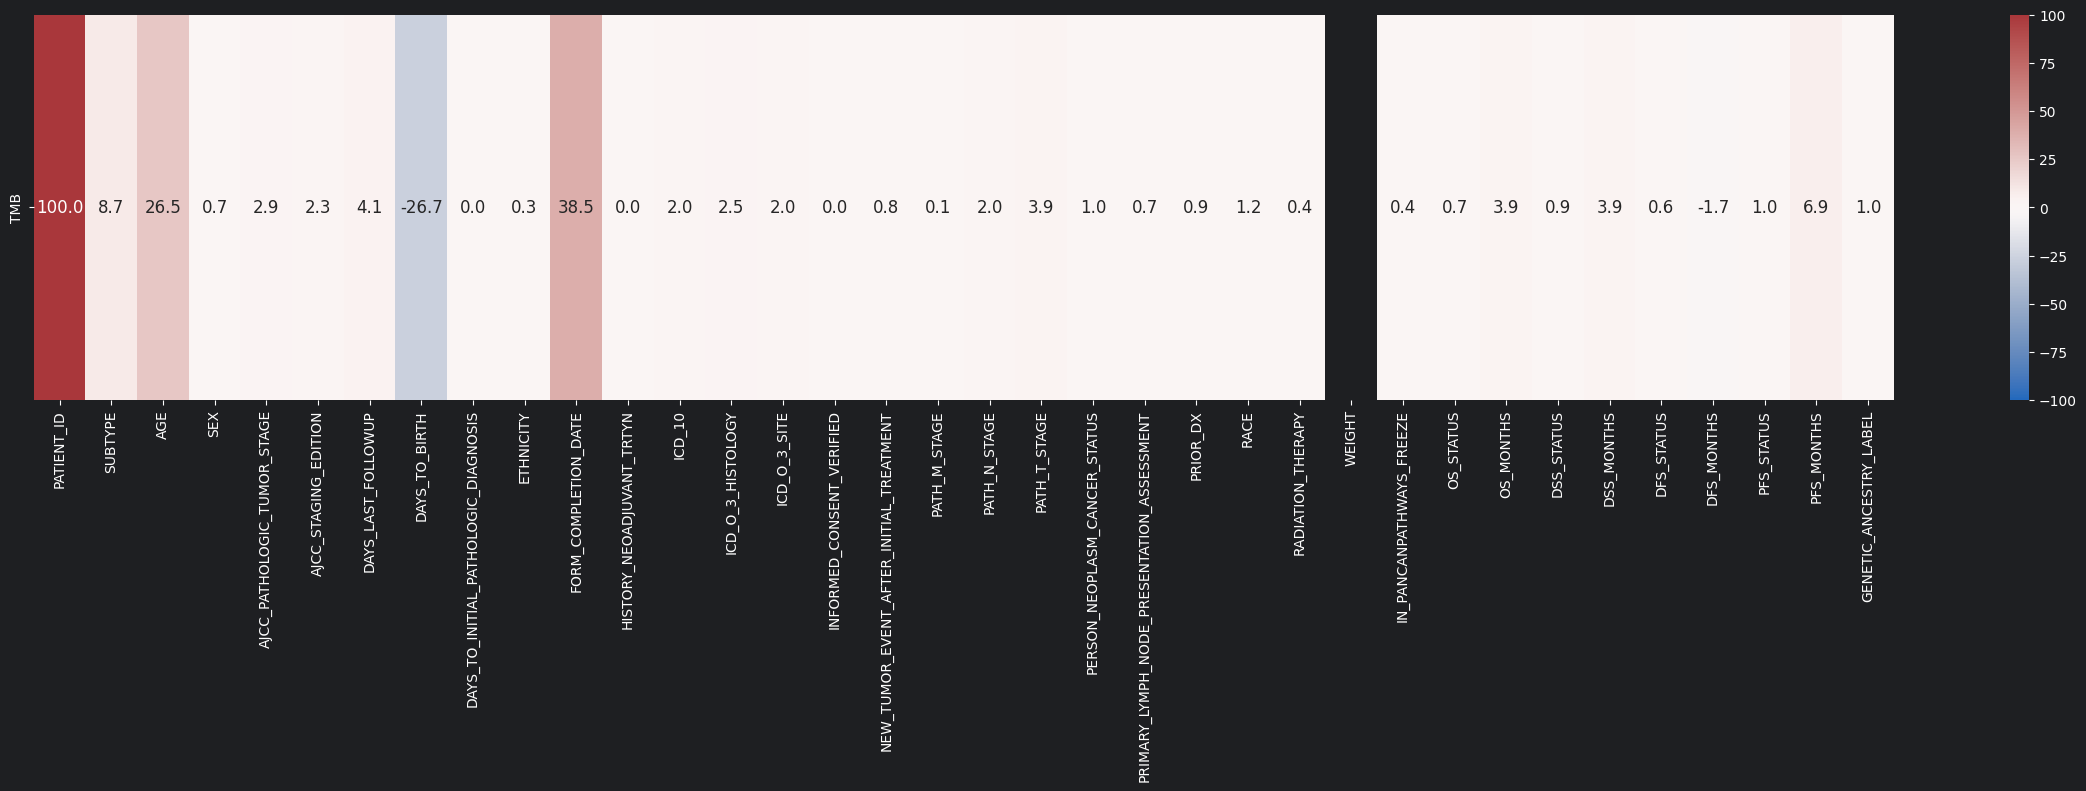

,PATIENT_ID,SUBTYPE,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,ETHNICITY,...,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL
type,numeric-categorical,numeric-categorical,numeric-numeric,numeric-categorical,numeric-categorical,numeric-categorical,numeric-numeric,numeric-numeric,numeric-numeric,numeric-categorical,...,numeric-categorical,numeric-categorical,numeric-numeric,numeric-categorical,numeric-numeric,numeric-categorical,numeric-numeric,numeric-categorical,numeric-numeric,numeric-categorical
correlation_ratio,100.0,8.675738,NaN,0.662566,2.881563,2.253062,NaN,NaN,NaN,0.315637,...,0.352654,0.658042,NaN,0.890912,NaN,0.607286,NaN,0.97808,NaN,1.018704
spearman,NaN,NaN,26.47449,NaN,NaN,NaN,4.103935,-26.650157,0.0,NaN,...,NaN,NaN,3.870946,NaN,3.870946,NaN,-1.650691,NaN,6.870705,NaN
TMB,100.0,8.675738,26.47449,0.662566,2.881563,2.253062,4.103935,-26.650157,0.0,0.315637,...,0.352654,0.658042,3.870946,0.890912,3.870946,0.607286,-1.650691,0.97808,6.870705,1.018704


In [28]:
multivariate_relationships(df, "TMB", "../../../assets//EDA-charts/stad-clinical-target-corr-heatmap.png")

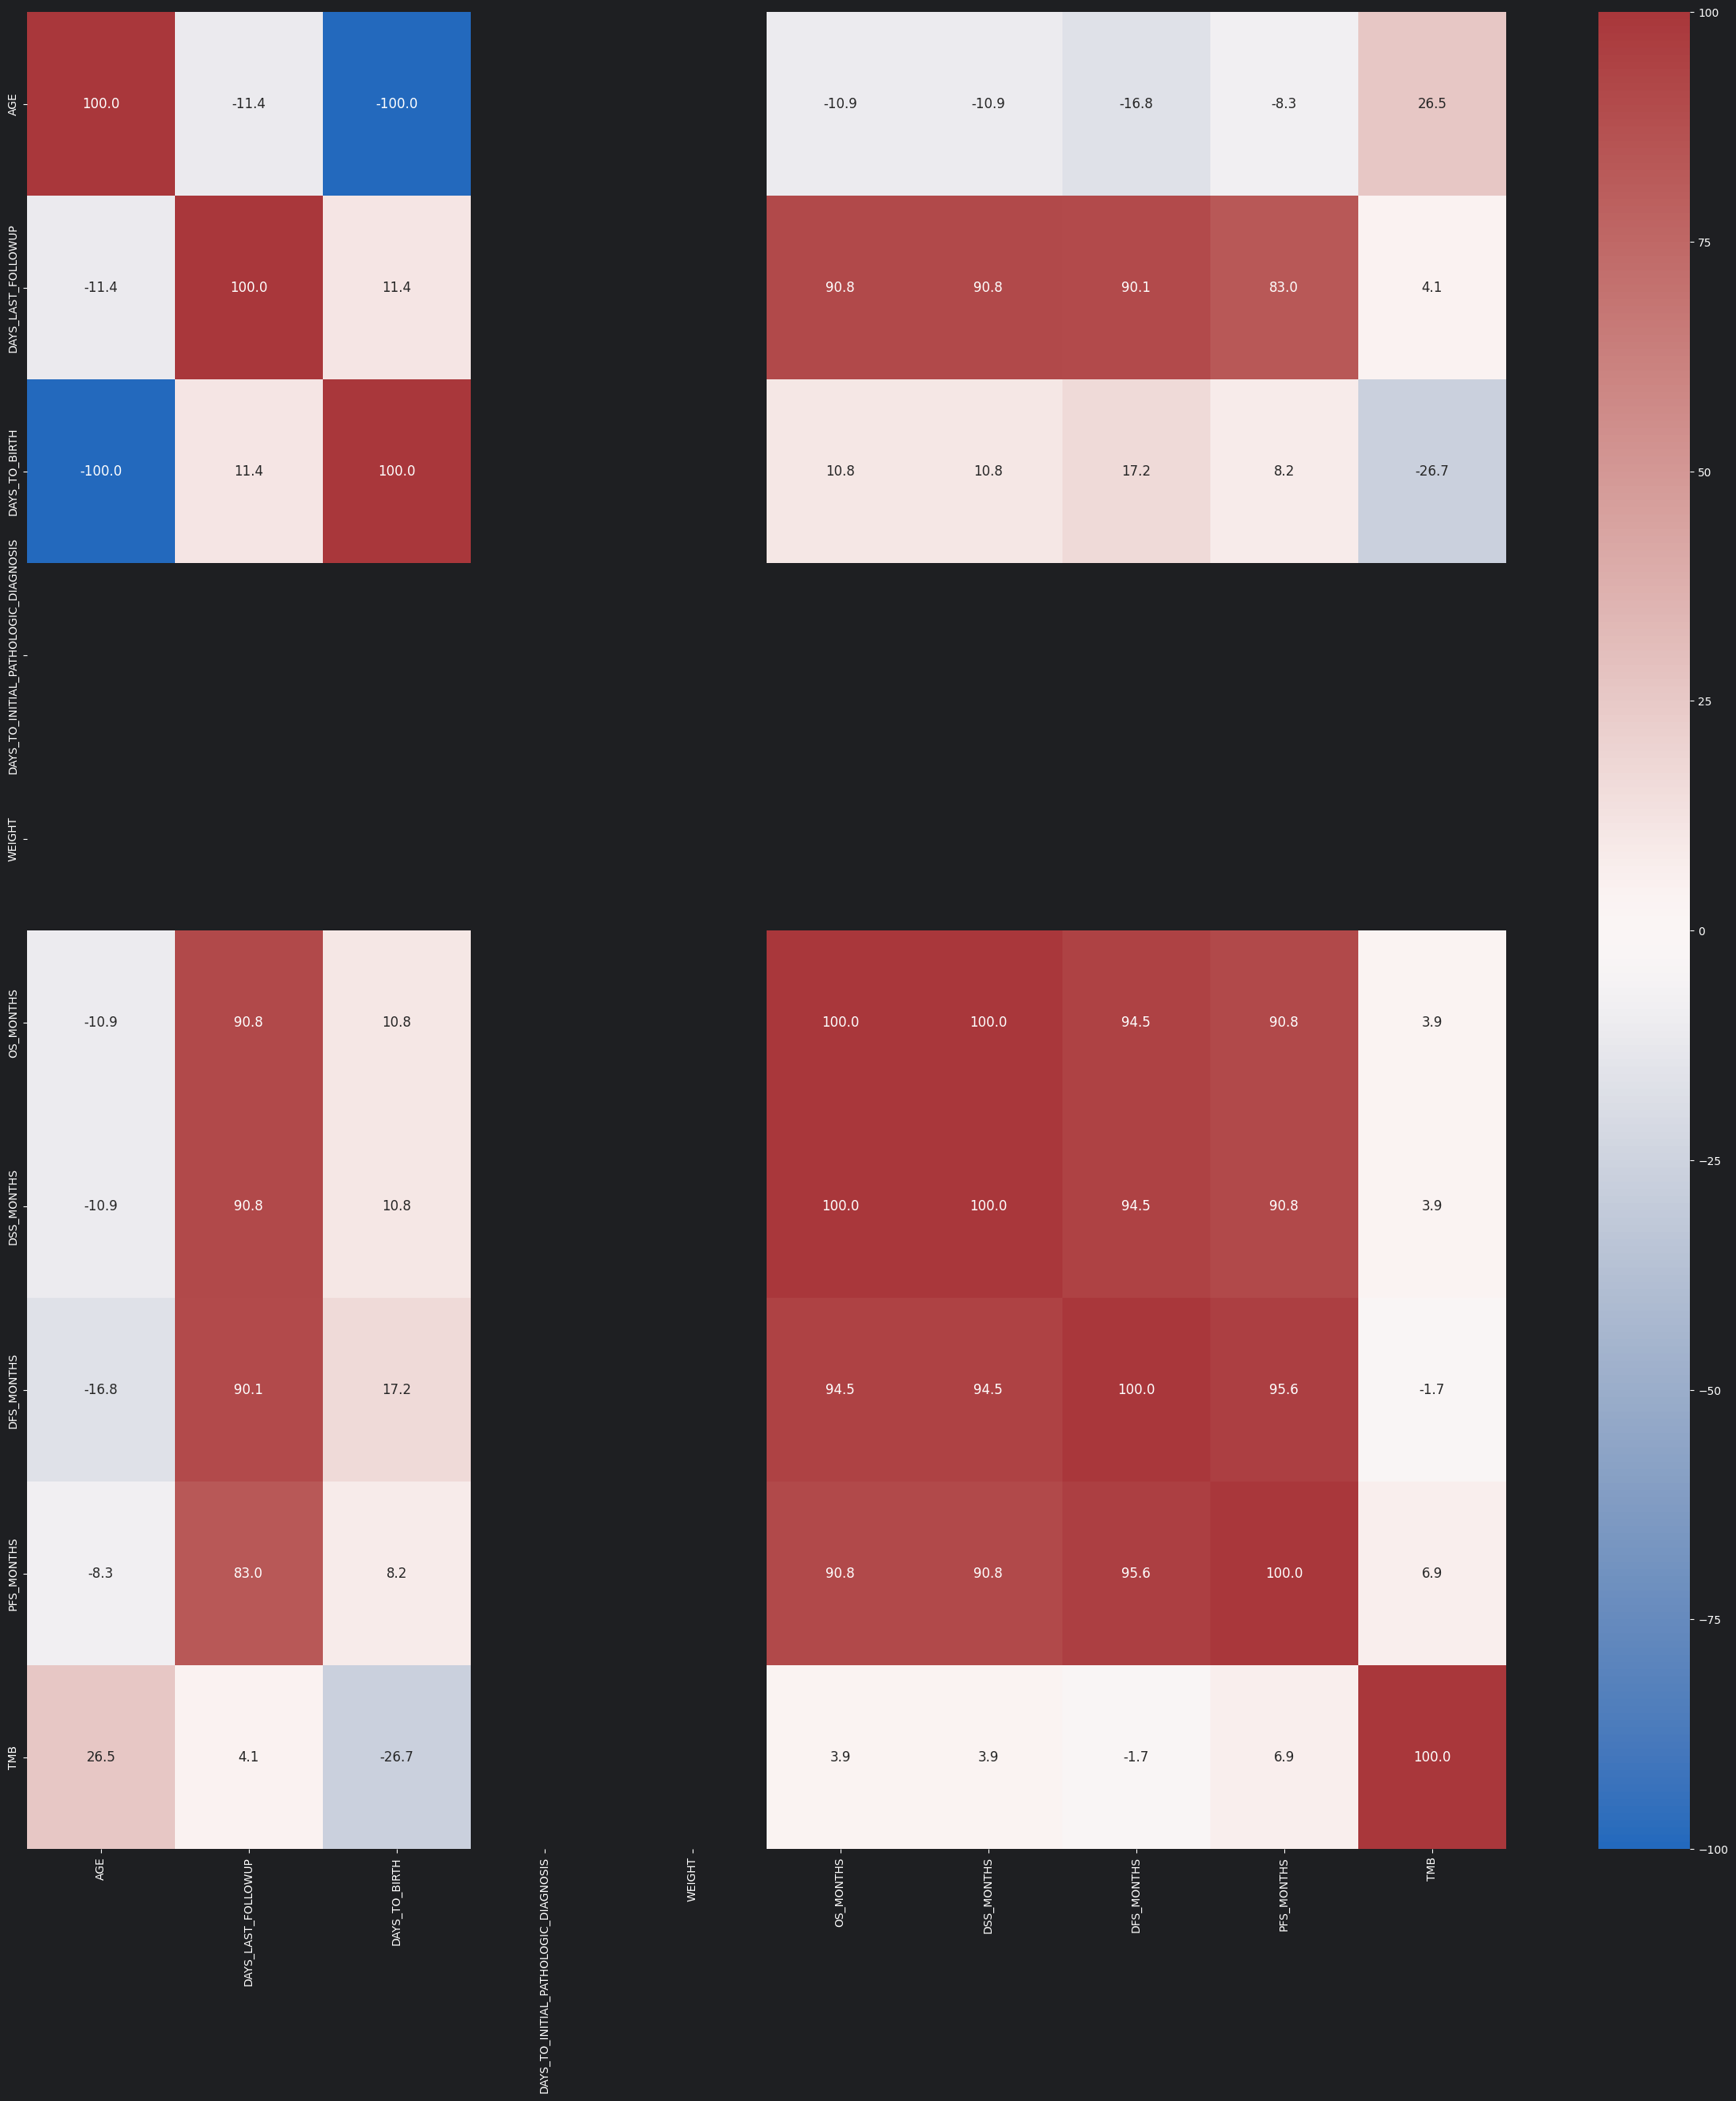

In [29]:
plt.figure(figsize=(30, 30))
sns.heatmap(df.corr(method='spearman', numeric_only=True)*100, annot=True, fmt=".1f", cmap="vlag", vmin=-100, vmax=100, cbar=True, annot_kws={"size": 12})
plt.savefig("../../../assets//EDA-charts/stad-clinical-numeric-corr-heatmap.png", dpi=300, bbox_inches="tight")

In [30]:
df.to_parquet("../../../data/processed/stad_clinical_patient.parquet", engine="pyarrow")